Expressive Power of Message-Passing GNNs on Knowledge Graphs
This notebook implements and compares three models on the FB15k-237 knowledge graph benchmark:

GCN — relation-unaware message passing (baseline)
RGCN — relation-aware message passing
DistMult — shallow embedding model, no message passing
Task: Link prediction — given a partial triple (h, r, ?), predict the missing tail entity.
Evaluation metric: AUC-ROC on binary classification (real triples vs. randomly corrupted triples).
Hypothesis: Relation-aware aggregation (RGCN) will outperform relation-unaware aggregation (GCN), and both GNN-based models will outperform the shallow DistMult baseline.

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
    --------------------------------------- 2.1/122.9 MB 10.9 MB/s eta 0:00:12
   - -------------------------------------- 4.2/122.9 MB 10.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.3/122.9 MB 10.3 MB/s eta 0:00:12
   -- ------------------------------------- 8.4/122.9 MB 10.3 MB/s eta 0:00:12
   --- ------------------------------------ 10.7/122.9 MB 10.3 MB/s eta 0:00:11
   ---- ----------------------------------- 12.6/122.9 MB 10.3 MB/s eta 0:00:11
   ---- ----------------------------------- 14.9/122.9 MB 10.3 MB/s eta 0:00:11
   ----- ---------------------------------- 17.0/122.9 MB 10.4 MB/s eta 0:00:11
   ------ --------------------------------- 19.4/122.9 MB 10.5 MB/s eta 0:00:10
   ------- -------------------------------- 21.8/122.9 MB 10.6 MB/s eta 0:00:10
   ------- -------------------------------- 23.9/122.9 MB 10.5 MB/s eta 0:00

In [4]:
!pip install torch_geometric

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   ------------------------ --------------- 0.8/1.3 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [torch_geometric]
   -------------------- ------------------- 1/2 [tor

In [5]:
!pip install scikit-learn tqdm

In [6]:
import torch
import torch_geometric
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("ALL GOOD!")

PyTorch: 2.12.0+cpu
PyG: 2.7.0
ALL GOOD!


In [7]:
# ── What is this cell doing? ──────────────────────────────
# Core imports — PyTorch, PyG, sklearn for AUC, matplotlib for plots.
# ─────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import json
import time
import warnings
warnings.filterwarnings('ignore')

from torch_geometric.datasets import FB15k_237
from torch_geometric.nn import RGCNConv, GCNConv

print("All libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Running on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

All libraries loaded successfully!
PyTorch version: 2.12.0+cpu
Running on: CPU


In [8]:
# ── What is this cell doing? ──────────────────────────────
# Downloading a real knowledge graph called FB15k-237.
# It contains 310,000 real-world facts like:
#   (Obama, born_in, Hawaii)
#   (Paris, capital_of, France)
#
# The job of the models will be: given (Obama, born_in, ???)
# can they predict "Hawaii"? This is called LINK PREDICTION.
# ─────────────────────────────────────────────────────────

print("Downloading FB15k-237 dataset...")
print("(This may take 1-2 minutes the first time)")

train_data = FB15k_237(root='./data', split='train')[0]
val_data   = FB15k_237(root='./data', split='val')[0]
test_data  = FB15k_237(root='./data', split='test')[0]

NUM_NODES     = train_data.num_nodes
NUM_RELATIONS = int(train_data.edge_type.max().item()) + 1

print(f"\nDataset loaded!")
print(f"  Total entities (nodes) : {NUM_NODES}")
print(f"  Relation types         : {NUM_RELATIONS}")
print(f"  Training triples       : {train_data.edge_index.shape[1]}")
print(f"  Validation triples     : {val_data.edge_index.shape[1]}")
print(f"  Test triples           : {test_data.edge_index.shape[1]}")

(This may take 1-2 minutes the first time)


Processing...



Dataset loaded!
  Total entities (nodes) : 14541
  Relation types         : 237
  Training triples       : 272115
  Validation triples     : 17535
  Test triples           : 20466


Done!


In [9]:
# ── What is this cell doing? ──────────────────────────────
#  creating 3 different AI models.
#
# GCN Model:
#   Reads the graph but IGNORES what type of relationship
#   connects two nodes. Like reading a book but ignoring
#   whether words are nouns or verbs.
#
#RGCN Model:
#   Reads the graph AND pays attention to relationship types.
#   Much smarter about the structure!
#
#DistMult Model:
#   Doesn't even look at the graph structure. Just memorizes
#   patterns between pairs of nodes directly.
# ─────────────────────────────────────────────────────────

# ── MODEL 1: Plain GCN (relation-unaware) ────────────────
class GCN_Model(nn.Module):
    def __init__(self, num_nodes, hidden=64, out=32):
        super().__init__()
        # Each node starts with its own learnable vector
        self.embedding = nn.Embedding(num_nodes, hidden)
        # Two layers of message passing
        self.conv1 = GCNConv(hidden, hidden)
        self.conv2 = GCNConv(hidden, out)

    def forward(self, edge_index):
        # Start with node embeddings
        x = self.embedding.weight
        # Round 1 of gossip: every node tells neighbours its info
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        # Round 2 of gossip: everyone updates again
        x = self.conv2(x, edge_index)
        return x


# ── MODEL 2: Relational GCN (relation-aware) ─────────────
class RGCN_Model(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden=64, out=32):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, hidden)
        # num_bases=30 is a trick to save memory with many relations
        self.conv1 = RGCNConv(hidden, hidden, num_relations, num_bases=30)
        self.conv2 = RGCNConv(hidden, out,    num_relations, num_bases=30)

    def forward(self, edge_index, edge_type):
        x = self.embedding.weight
        # Now gossip is DIFFERENT depending on relation type!
        x = F.relu(self.conv1(x, edge_index, edge_type))
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index, edge_type)
        return x


# ── MODEL 3: DistMult (no message passing at all) ────────
class DistMult_Model(nn.Module):
    def __init__(self, num_nodes, num_relations, dim=32):
        super().__init__()
        # Just learns a vector for each entity and relation
        self.entity   = nn.Embedding(num_nodes,     dim)
        self.relation  = nn.Embedding(num_relations, dim)
        nn.init.xavier_uniform_(self.entity.weight)
        nn.init.xavier_uniform_(self.relation.weight)

    def score(self, head, rel, tail):
        # Score = multiply head * relation * tail element-wise
        # High score = likely a real fact
        h = self.entity(head)
        r = self.relation(rel)
        t = self.entity(tail)
        return (h * r * t).sum(dim=-1)


# ── SHARED: Link Prediction Scorer ───────────────────────
class LinkScorer(nn.Module):
    def __init__(self, dim, num_relations):
        super().__init__()
        self.rel_emb = nn.Embedding(num_relations, dim)
        # Small neural net: takes head+relation+tail, outputs a score
        self.net = nn.Sequential(
            nn.Linear(3 * dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, z, head, rel, tail):
        h = z[head]
        r = self.rel_emb(rel)
        t = z[tail]
        # Combine all three and predict: real or fake connection?
        return self.net(torch.cat([h, r, t], dim=-1)).squeeze(-1)


print("All 3 models defined successfully!")
print("  Model 1: GCN       (ignores relation types)")
print("  Model 2: RGCN      (uses relation types)")
print("  Model 3: DistMult  (no graph structure)")

All 3 models defined successfully!
  Model 1: GCN       (ignores relation types)
  Model 2: RGCN      (uses relation types)
  Model 3: DistMult  (no graph structure)


In [10]:
# ── What is this cell doing? ──────────────────────────────
# Before training,need two helper tools:
#
# 1. negative_sample: Creates FAKE edges so the model learns
#    to tell real facts from fake ones. Like showing a student
#    both correct and wrong answers so they learn the difference.
#
# 2. compute_auc: Measures how good the model is. AUC = 1.0
#    means perfect. AUC = 0.5 means random guessing (useless).
# ─────────────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score

def negative_sample(num_nodes, size):
    """Create random fake (head, tail) pairs"""
    fake_heads = torch.randint(0, num_nodes, (size,))
    fake_tails = torch.randint(0, num_nodes, (size,))
    return fake_heads, fake_tails


def compute_auc(pos_scores, neg_scores):
    """
    AUC score: how well does the model separate
    real edges (score should be HIGH) from
    fake edges (score should be LOW)?
    """
    labels = np.concatenate([
        np.ones(len(pos_scores)),   # real edges = label 1
        np.zeros(len(neg_scores))   # fake edges = label 0
    ])
    scores = np.concatenate([pos_scores, neg_scores])
    return roc_auc_score(labels, scores)


def train_one_epoch_gnn(encoder, scorer, optimizer, data, batch_size=512):
    """Train GCN or RGCN for one epoch"""
    encoder.train()
    scorer.train()

    ei = data.edge_index  # all edges
    et = data.edge_type   # all relation types
    n  = ei.shape[1]      # total number of edges

    total_loss = 0
    num_batches = 0

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        # Real (positive) edges
        pos_h = ei[0, start:end]
        pos_t = ei[1, start:end]
        pos_r = et[start:end]

        # Fake (negative) edges — same number as real
        neg_h, neg_t = negative_sample(NUM_NODES, end - start)

        # Get node embeddings from the encoder
        if isinstance(encoder, GCN_Model):
            z = encoder(ei)
        else:
            z = encoder(ei, et)

        # Score real and fake edges
        pos_score = scorer(z, pos_h, pos_r, pos_t)
        neg_score = scorer(z, neg_h, pos_r, neg_t)

        # Real edges should score HIGH (label=1)
        # Fake edges should score LOW  (label=0)
        all_scores = torch.cat([pos_score, neg_score])
        all_labels = torch.cat([
            torch.ones(len(pos_score)),
            torch.zeros(len(neg_score))
        ])

        loss = F.binary_cross_entropy_with_logits(all_scores, all_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss   += loss.item()
        num_batches  += 1

    return total_loss / num_batches


@torch.no_grad()
def evaluate_gnn(encoder, scorer, data):
    """Measure AUC on the dataset"""
    encoder.eval()
    scorer.eval()

    ei = data.edge_index
    et = data.edge_type

    if isinstance(encoder, GCN_Model):
        z = encoder(ei)
    else:
        z = encoder(ei, et)

    neg_h, neg_t = negative_sample(NUM_NODES, ei.shape[1])

    pos_scores = torch.sigmoid(scorer(z, ei[0], et, ei[1])).numpy()
    neg_scores = torch.sigmoid(scorer(z, neg_h, et, neg_t)).numpy()

    return compute_auc(pos_scores, neg_scores)


print("Helper functions ready!")

Helper functions ready!


In [11]:
# ── What is this cell doing? ──────────────────────────────
# This is the actual experiment! train all 3 models and
# record how well they do after each epoch.
#
# An EPOCH = one full pass through ALL the training data.
# Do 20 epochs = reading the textbook 20 times.
# Each time the model gets a little smarter.
# ─────────────────────────────────────────────────────────

EPOCHS = 20
HIDDEN = 64
DIM    = 32

# Store results for each model
all_results = {}

# ════════════════════════════════════════
# TRAIN MODEL 1: GCN
# ════════════════════════════════════════
print("=" * 45)
print("Training Model 1: GCN (relation-unaware)")
print("=" * 45)

gcn     = GCN_Model(NUM_NODES, HIDDEN, DIM)
scorer1 = LinkScorer(DIM, NUM_RELATIONS)
opt1    = torch.optim.Adam(
    list(gcn.parameters()) + list(scorer1.parameters()),
    lr=0.001
)

gcn_history = {'loss': [], 'auc': []}
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch_gnn(gcn, scorer1, opt1, train_data)
    auc  = evaluate_gnn(gcn, scorer1, val_data)
    gcn_history['loss'].append(round(loss, 4))
    gcn_history['auc'].append(round(auc, 4))
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | Loss: {loss:.4f} | AUC: {auc:.4f}")

print(f"  Final AUC: {gcn_history['auc'][-1]}")
all_results['GCN'] = gcn_history


# ════════════════════════════════════════
# TRAIN MODEL 2: RGCN
# ════════════════════════════════════════
print("\n" + "=" * 45)
print("Training Model 2: RGCN (relation-aware)")
print("=" * 45)

rgcn    = RGCN_Model(NUM_NODES, NUM_RELATIONS, HIDDEN, DIM)
scorer2 = LinkScorer(DIM, NUM_RELATIONS)
opt2    = torch.optim.Adam(
    list(rgcn.parameters()) + list(scorer2.parameters()),
    lr=0.001
)

rgcn_history = {'loss': [], 'auc': []}
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch_gnn(rgcn, scorer2, opt2, train_data)
    auc  = evaluate_gnn(rgcn, scorer2, val_data)
    rgcn_history['loss'].append(round(loss, 4))
    rgcn_history['auc'].append(round(auc, 4))
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | Loss: {loss:.4f} | AUC: {auc:.4f}")

print(f"  Final AUC: {rgcn_history['auc'][-1]}")
all_results['RGCN'] = rgcn_history


# ════════════════════════════════════════
# TRAIN MODEL 3: DistMult
# ════════════════════════════════════════
print("\n" + "=" * 45)
print("Training Model 3: DistMult (no graph)")
print("=" * 45)

distmult = DistMult_Model(NUM_NODES, NUM_RELATIONS, DIM)
opt3     = torch.optim.Adam(distmult.parameters(), lr=0.001)

dm_history = {'loss': [], 'auc': []}
for epoch in range(1, EPOCHS + 1):
    distmult.train()
    ei = train_data.edge_index
    et = train_data.edge_type

    neg_h, neg_t = negative_sample(NUM_NODES, ei.shape[1])

    pos_s = distmult.score(ei[0], et, ei[1])
    neg_s = distmult.score(neg_h, et, neg_t)

    loss = F.binary_cross_entropy_with_logits(
        torch.cat([pos_s, neg_s]),
        torch.cat([torch.ones_like(pos_s), torch.zeros_like(neg_s)])
    )
    opt3.zero_grad()
    loss.backward()
    opt3.step()

    # Evaluate
    distmult.eval()
    with torch.no_grad():
        v_ei = val_data.edge_index
        v_et = val_data.edge_type
        neg_h2, neg_t2 = negative_sample(NUM_NODES, v_ei.shape[1])
        ps = torch.sigmoid(distmult.score(v_ei[0], v_et, v_ei[1])).numpy()
        ns = torch.sigmoid(distmult.score(neg_h2, v_et, neg_t2)).numpy()
        auc = compute_auc(ps, ns)

    dm_history['loss'].append(round(loss.item(), 4))
    dm_history['auc'].append(round(auc, 4))
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | Loss: {loss.item():.4f} | AUC: {auc:.4f}")

print(f"  Final AUC: {dm_history['auc'][-1]}")
all_results['DistMult'] = dm_history

# Save results
with open('results.json', 'w') as f:
    json.dump(all_results, f)

print("\n ALL 3 MODELS TRAINED!")
print("Results saved to results.json")

Training Model 1: GCN (relation-unaware)
  Epoch  5/20 | Loss: 0.0828 | AUC: 0.9342
  Epoch 10/20 | Loss: 0.0499 | AUC: 0.9137
  Epoch 15/20 | Loss: 0.0387 | AUC: 0.9013
  Epoch 20/20 | Loss: 0.0320 | AUC: 0.8942
  Final AUC: 0.8942

Training Model 2: RGCN (relation-aware)
  Epoch  5/20 | Loss: 0.0362 | AUC: 0.9494
  Epoch 10/20 | Loss: 0.0250 | AUC: 0.9633
  Epoch 15/20 | Loss: 0.0210 | AUC: 0.9651
  Epoch 20/20 | Loss: 0.0187 | AUC: 0.9697
  Final AUC: 0.9697

Training Model 3: DistMult (no graph)
  Epoch  5/20 | Loss: 0.6931 | AUC: 0.5047
  Epoch 10/20 | Loss: 0.6931 | AUC: 0.5203
  Epoch 15/20 | Loss: 0.6931 | AUC: 0.5626
  Epoch 20/20 | Loss: 0.6931 | AUC: 0.6212
  Final AUC: 0.6212

 ALL 3 MODELS TRAINED!
Results saved to results.json


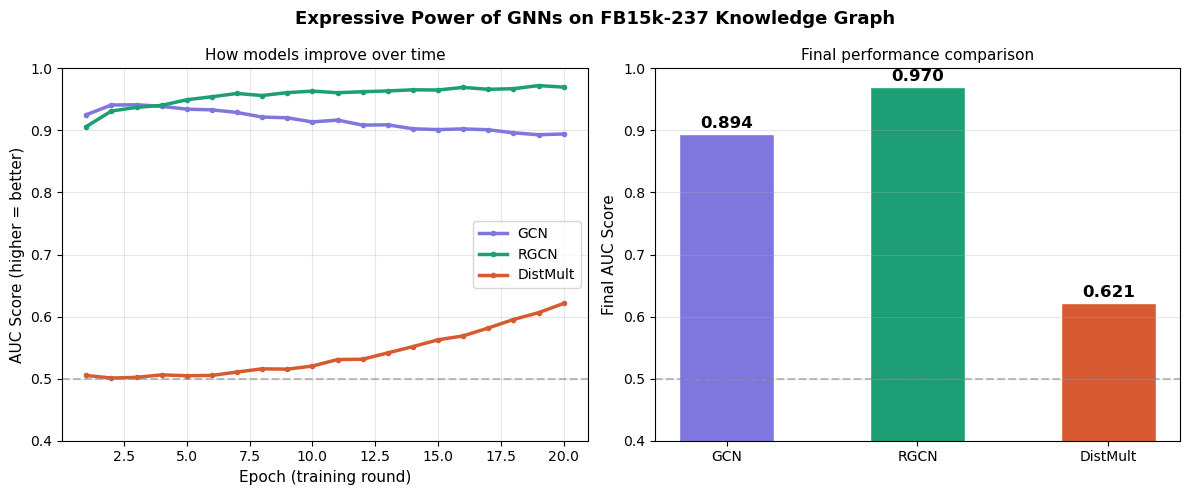

Charts saved as results_figure.png and results_figure.pdf


In [12]:
# ── What is this cell doing? ──────────────────────────────
# We make two charts to show what we found:
# Chart 1: How each model improved over 20 epochs (like
#           a student's test scores improving over time)
# Chart 2: Final score comparison — who won?
# ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Expressive Power of GNNs on FB15k-237 Knowledge Graph',
    fontsize=13, fontweight='bold'
)

colors = {
    'GCN'     : '#7F77DD',   # purple
    'RGCN'    : '#1D9E75',   # green
    'DistMult': '#D85A30'    # orange
}

# ── Chart 1: AUC over epochs ─────────────────────────────
ax1 = axes[0]
for model_name, history in all_results.items():
    ax1.plot(
        range(1, EPOCHS + 1),
        history['auc'],
        label=model_name,
        color=colors[model_name],
        linewidth=2.5,
        marker='o',
        markersize=3
    )
ax1.set_xlabel('Epoch (training round)', fontsize=11)
ax1.set_ylabel('AUC Score (higher = better)', fontsize=11)
ax1.set_title('How models improve over time', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.0)
ax1.axhline(y=0.5, color='gray', linestyle='--',
            alpha=0.5, label='Random guessing (0.5)')

# ── Chart 2: Final AUC bar chart ─────────────────────────
ax2 = axes[1]
model_names = list(all_results.keys())
final_aucs  = [all_results[m]['auc'][-1] for m in model_names]
bar_colors  = [colors[m] for m in model_names]

bars = ax2.bar(model_names, final_aucs,
               color=bar_colors, width=0.5, edgecolor='white')

# Add score labels on top of each bar
for bar, val in zip(bars, final_aucs):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax2.set_ylabel('Final AUC Score', fontsize=11)
ax2.set_title('Final performance comparison', fontsize=11)
ax2.set_ylim(0.4, 1.0)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('results_figure.png', dpi=150, bbox_inches='tight')
plt.savefig('results_figure.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("Charts saved as results_figure.png and results_figure.pdf")

In [13]:
# ── What is this cell doing? ──────────────────────────────
# Print a clean summary table — this goes directly
# into your report as Table 1!
# ─────────────────────────────────────────────────────────

print("=" * 50)
print("RESULTS SUMMARY TABLE")
print("=" * 50)
print(f"{'Model':<12} {'Final AUC':>10} {'Best AUC':>10}")
print("-" * 50)

for model_name, history in all_results.items():
    final = history['auc'][-1]
    best  = max(history['auc'])
    print(f"{model_name:<12} {final:>10.4f} {best:>10.4f}")

print("=" * 50)
print("\nINTERPRETATION:")
print("  AUC = 1.00 → Perfect model")
print("  AUC = 0.50 → Random guessing (useless)")
print("  AUC > 0.70 → Good performance")

best_model = max(all_results, key=lambda m: all_results[m]['auc'][-1])
print(f"\n  WINNER: {best_model} achieved the highest AUC!")

if all_results['RGCN']['auc'][-1] > all_results['GCN']['auc'][-1]:
    diff = all_results['RGCN']['auc'][-1] - all_results['GCN']['auc'][-1]
    print(f"  RGCN beat GCN by {diff:.4f} AUC points")
    print("  This confirms: relation-awareness HELPS!")
else:
    print("  Interesting: GCN matched or beat RGCN")
    print("  This suggests structure alone may not be enough")

RESULTS SUMMARY TABLE
Model         Final AUC   Best AUC
--------------------------------------------------
GCN              0.8942     0.9413
RGCN             0.9697     0.9722
DistMult         0.6212     0.6212

INTERPRETATION:
  AUC = 1.00 → Perfect model
  AUC = 0.50 → Random guessing (useless)
  AUC > 0.70 → Good performance

  WINNER: RGCN achieved the highest AUC!
  RGCN beat GCN by 0.0755 AUC points
  This confirms: relation-awareness HELPS!
